# FIFA 21 Data Cleaning & Preprocessing

This notebook provides a comprehensive data cleaning pipeline for the FIFA 21 dataset. We will handle missing values, outliers, duplicates, and prepare the data for machine learning tasks.

## Step 1: Import Required Libraries

Import essential libraries for data manipulation (pandas, numpy) and visualization (matplotlib)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# import seaborn as sns

## Step 2: Load the Dataset

Load the raw FIFA 21 dataset from CSV file

In [13]:
data  = pd.read_csv('fifa21 raw data v2.csv')

C:\Users\sujay\AppData\Local\Temp\ipykernel_15108\3368706192.py:1: DtypeWarning: Columns (76) have mixed types. Specify dtype option on import or set low_memory=False.
  data  = pd.read_csv('fifa21 raw data v2.csv')


## Step 3: Exploratory Data Analysis (EDA) - First Look

Display the first few rows to understand the dataset structure and content

In [26]:
data.head()

,ID,Name,LongName,photoUrl,playerUrl,Nationality,Age,↓OVA,POT,Club,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,158023,L. Messi,Lionel Messi,https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,33,93,93,\n\n\n\nFC Barcelona,...,Medium,Low,5 ★,85,92,91,95,38,65,771
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,35,92,92,\n\n\n\nJuventus,...,High,Low,5 ★,89,93,81,89,35,77,562
2,200389,J. Oblak,Jan Oblak,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Slovenia,27,91,93,\n\n\n\nAtlético Madrid,...,Medium,Medium,3 ★,87,92,78,90,52,90,150
3,192985,K. De Bruyne,Kevin De Bruyne,https://cdn.sofifa.com/players/192/985/21_60.png,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,29,91,91,\n\n\n\nManchester City,...,High,High,4 ★,76,86,93,88,64,78,207
4,190871,Neymar Jr,Neymar da Silva Santos Jr.,https://cdn.sofifa.com/players/190/871/21_60.png,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,28,91,91,\n\n\n\nParis Saint-Germain,...,High,Medium,5 ★,91,85,86,94,36,59,595


## Step 4: Statistical Summary

Display descriptive statistics (mean, median, std, min, max) for numeric columns

In [15]:
data.describe()

,ID,Age,↓OVA,POT,BOV,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,...,GK Positioning,GK Reflexes,Total Stats,Base Stats,PAC,SHO,PAS,DRI,DEF,PHY
count,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,...,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000
mean,226403.384794,25.194109,65.718636,71.136414,66.751726,248.938142,49.688392,45.842405,51.942726,58.768112,...,16.217187,16.519627,1595.286949,355.702197,67.453975,53.457031,57.681016,62.875020,49.866221,64.368934
std,27141.054157,4.710520,6.968999,6.114635,6.747193,74.299428,18.131153,19.567081,17.294409,14.519106,...,17.002239,17.854079,269.874789,40.761117,10.677859,13.827425,10.081857,9.927415,16.443213,9.601883
min,41.000000,16.000000,47.000000,47.000000,48.000000,42.000000,6.000000,3.000000,5.000000,7.000000,...,2.000000,2.000000,747.000000,232.000000,25.000000,16.000000,25.000000,25.000000,12.000000,28.000000
25%,210135.000000,21.000000,61.000000,67.000000,62.000000,222.000000,38.000000,30.000000,44.000000,54.000000,...,8.000000,8.000000,1452.000000,327.000000,61.000000,44.000000,51.000000,57.000000,35.000000,58.000000
50%,232418.000000,25.000000,66.000000,71.000000,67.000000,263.000000,54.000000,49.000000,55.000000,62.000000,...,11.000000,11.000000,1627.000000,356.000000,68.000000,56.000000,58.000000,64.000000,53.000000,65.000000
75%,246922.500000,29.000000,70.000000,75.000000,71.000000,297.000000,63.000000,62.000000,64.000000,68.000000,...,14.000000,14.000000,1781.000000,384.000000,75.000000,64.000000,64.000000,69.000000,63.000000,71.000000
max,259216.000000,53.000000,93.000000,95.000000,93.000000,437.000000,94.000000,95.000000,93.000000,94.000000,...,91.000000,90.000000,2316.000000,498.000000,96.000000,93.000000,93.000000,95.000000,91.000000,91.000000


## Step 5: Data Info and Data Types

Check data types, non-null counts, and memory usage for all columns

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18979 entries, 0 to 18978
Data columns (total 77 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                18979 non-null  int64 
 1   Name              18979 non-null  object
 2   LongName          18979 non-null  object
 3   photoUrl          18979 non-null  object
 4   playerUrl         18979 non-null  object
 5   Nationality       18979 non-null  object
 6   Age               18979 non-null  int64 
 7   ↓OVA              18979 non-null  int64 
 8   POT               18979 non-null  int64 
 9   Club              18979 non-null  object
 10  Contract          18979 non-null  object
 11  Positions         18979 non-null  object
 12  Height            18979 non-null  object
 13  Weight            18979 non-null  object
 14  Preferred Foot    18979 non-null  object
 15  BOV               18979 non-null  int64 
 16  Best Position     18979 non-null  object
 17  Joined      

## Step 6: Correlation Analysis

Calculate correlation matrix for numeric columns to identify relationships

In [16]:
data.corr(numeric_only=True)

,ID,Age,↓OVA,POT,BOV,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,...,GK Positioning,GK Reflexes,Total Stats,Base Stats,PAC,SHO,PAS,DRI,DEF,PHY
ID,1.000000,-0.753413,-0.486968,0.023736,-0.443686,-0.180955,-0.156939,-0.117892,-0.140575,-0.173973,...,-0.123415,-0.110397,-0.291523,-0.434793,0.079109,-0.308248,-0.399298,-0.291203,-0.216042,-0.399517
Age,-0.753413,1.000000,0.466140,-0.269473,0.401796,0.146765,0.124639,0.081765,0.146402,0.142810,...,0.129497,0.117392,0.249822,0.390236,-0.129725,0.265495,0.350054,0.214831,0.223683,0.445806
↓OVA,-0.486968,0.466140,1.000000,0.632166,0.987149,0.446337,0.406600,0.323638,0.325182,0.500041,...,0.013473,0.006018,0.620825,0.845894,0.266494,0.479176,0.698816,0.654745,0.363017,0.572159
POT,0.023736,-0.269473,0.632166,1.000000,0.669677,0.284542,0.255631,0.216708,0.179505,0.351508,...,-0.036007,-0.037498,0.382014,0.520473,0.305882,0.275101,0.428741,0.479501,0.188153,0.205002
BOV,-0.443686,0.401796,0.987149,0.669677,1.000000,0.487301,0.423047,0.363071,0.364678,0.546180,...,-0.039552,-0.047385,0.653336,0.841199,0.274963,0.470838,0.687184,0.648649,0.367787,0.565163
Attacking,-0.180955,0.146765,0.446337,0.284542,0.487301,1.000000,0.854188,0.884985,0.732720,0.891484,...,-0.772999,-0.778203,0.915037,0.449376,0.247001,0.310854,0.352705,0.374304,0.158966,0.155766
Crossing,-0.156939,0.124639,0.406600,0.255631,0.423047,0.854188,1.000000,0.671208,0.481819,0.803686,...,-0.664975,-0.668438,0.860269,0.495865,0.359221,0.184679,0.477882,0.435445,0.255859,0.049441
Finishing,-0.117892,0.081765,0.323638,0.216708,0.363071,0.884985,0.671208,1.000000,0.486460,0.675865,...,-0.593090,-0.596803,0.734163,0.389296,0.329846,0.575033,0.325464,0.466847,-0.201657,-0.021363
Heading Accuracy,-0.140575,0.146402,0.325182,0.179505,0.364678,0.732720,0.481819,0.486460,1.000000,0.668567,...,-0.737408,-0.742600,0.650507,0.139366,-0.111660,-0.140723,-0.089542,-0.124150,0.418076,0.424872
Short Passing,-0.173973,0.142810,0.500041,0.351508,0.546180,0.891484,0.803686,0.675865,0.668567,1.000000,...,-0.730428,-0.736255,0.906892,0.486925,0.158781,0.129623,0.438534,0.342877,0.392135,0.217328


## Step 7: Detect Missing Values

Count missing (null) values in each column to identify data quality issues

In [35]:
data.isna().sum()


ID           0
Name         0
LongName     0
photoUrl     0
playerUrl    0
            ..
PAS          0
DRI          0
DEF          0
PHY          0
Hits         0
Length: 77, dtype: int64

## Step 8: Detect Duplicate Rows

Count the number of duplicate rows in the dataset

In [66]:
data.duplicated().sum()
data.drop_duplicates(inplace=True)

## Step 9: Identify Columns with Missing Values

Get a list of column names that contain null values

In [37]:
cols = data.columns[data.isnull().any()].tolist()

### Display Column Names with Missing Values

Print the list of columns that have null values

In [38]:
cols

[]

## Step 10: Handle Missing Values

Fill missing values using:
- **Mode** for categorical columns (most frequent value)
- **Mean** for numeric columns (average value)

In [39]:
for i in cols:
    if data[i].dtype == 'object':
        data[i].fillna(data[i].mode()[0], inplace=True)
    else:
        data[i].fillna(data[i].mean(), inplace=True)

## Step 11: Select Numeric Columns

Extract only numeric (non-object) columns for outlier detection

In [40]:
cols = data.columns[data.dtypes != 'object'].tolist()

## Step 12: Visualize Outliers Using Boxplots

Display boxplots for all numeric columns to visually identify outliers

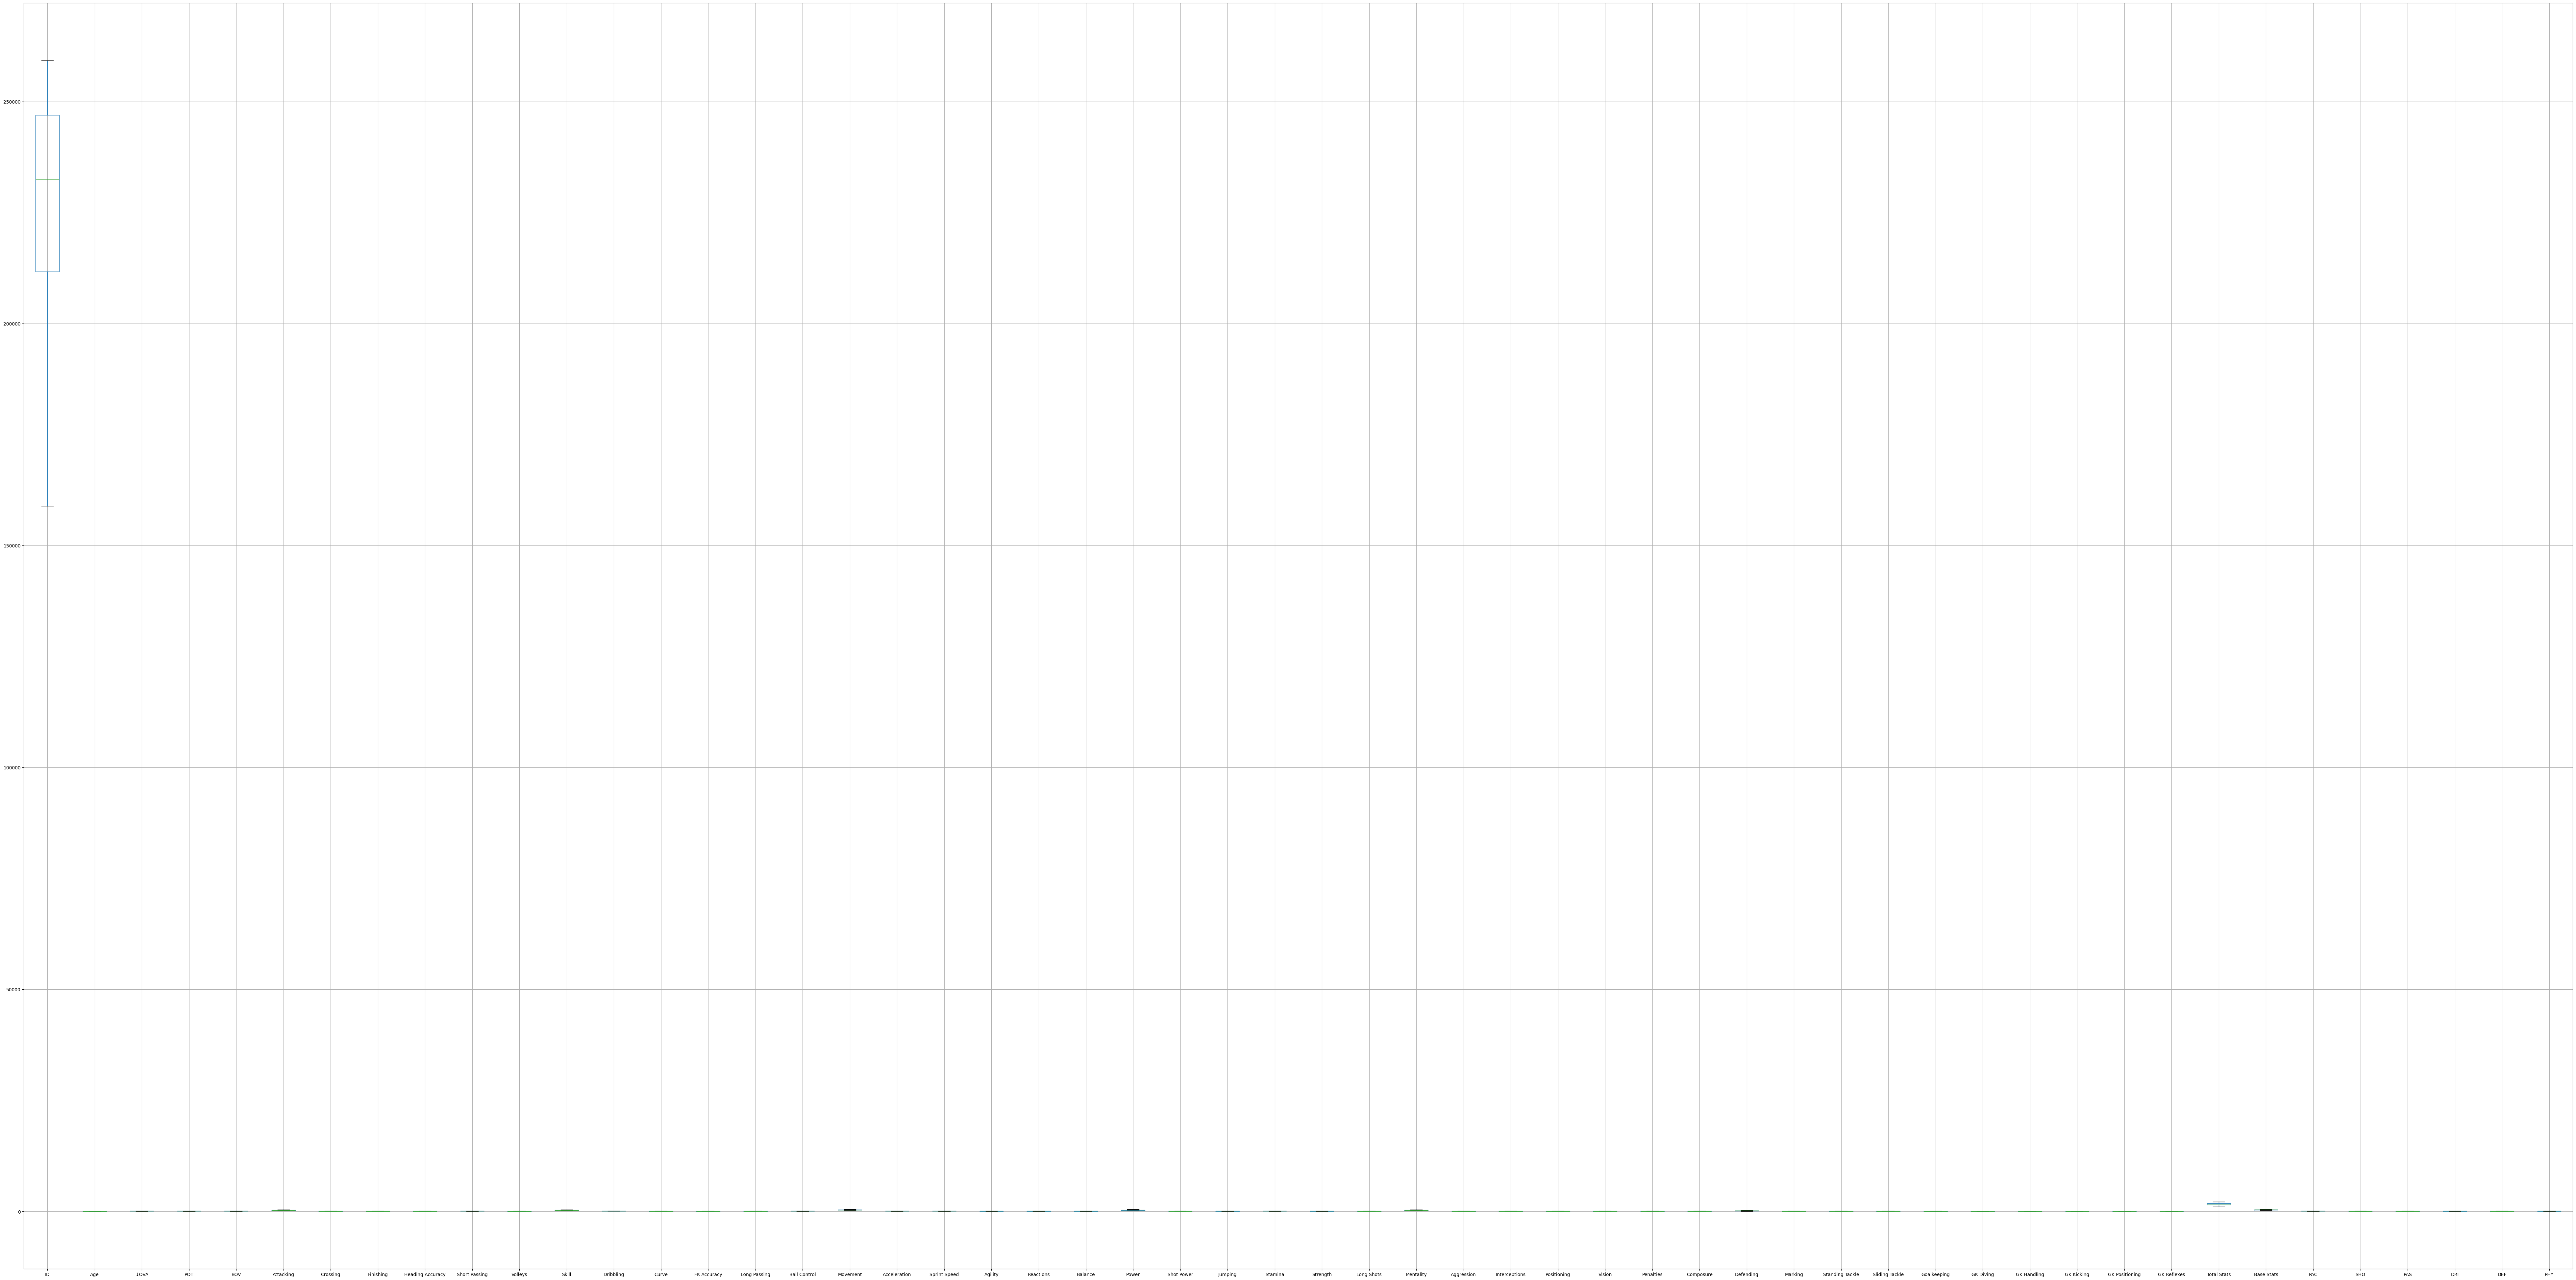

In [65]:
#find the outliers in the numeric columns using boxplot
data.boxplot(column=cols, figsize=(100,50))
plt.show()

## Step 13: Handle Outliers Using IQR Method

Treat outliers by replacing values beyond 1.5 × IQR bounds with the median value:
- **Q1**: 25th percentile
- **Q3**: 75th percentile
- **IQR**: Q3 - Q1
- **Lower Bound**: Q1 - 1.5 × IQR
- **Upper Bound**: Q3 + 1.5 × IQR

In [64]:
for i in cols:
    q1 = data[i].quantile(0.25)
    q3 = data[i].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    data[i] = np.where((data[i] < lower_bound) | (data[i] > upper_bound), data[i].median(), data[i])

In [68]:
cols = data.columns[data.dtypes == 'object'].tolist()
for i in cols:
    data[i] = data[i].str.strip()
    